# Energy Consumption Analysis & Prediction

**Dataset:** Tetouan City Power Consumption (Morocco, 2017)  
**Goal:** Analyze and predict energy consumption patterns across three distribution zones.  

---

## ML Pipeline
1. Problem Definition  
2. Data Loading & Preparation  
3. Exploratory Data Analysis (EDA)  
4. Feature Engineering  
5. Train / Test Split  
6. Model Selection & Training  
7. Model Evaluation  
8. Hyperparameter Tuning  
9. Visualization of Results  


---
## Problem Definition

**Objective:** Predict power consumption (kW) for Zone 1, Zone 2, and Zone 3 using weather and temporal features.  
**Problem Type:** Multi-output Time-Series Regression  
**Targets:** `PowerConsumption_Zone1`, `PowerConsumption_Zone2`, `PowerConsumption_Zone3`


---
## Data Loading & Preparation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid', palette='muted')
SEED = 42
np.random.seed(SEED)


In [3]:
df = pd.read_csv('powerconsumption.csv', parse_dates=['Datetime'], infer_datetime_format=True)
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape: {df.shape}')
df.head()


Shape: (52416, 9)


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [4]:
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().round(2)


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Datetime                52416 non-null  datetime64[ns]
 1   Temperature             52416 non-null  float64       
 2   Humidity                52416 non-null  float64       
 3   WindSpeed               52416 non-null  float64       
 4   GeneralDiffuseFlows     52416 non-null  float64       
 5   DiffuseFlows            52416 non-null  float64       
 6   PowerConsumption_Zone1  52416 non-null  float64       
 7   PowerConsumption_Zone2  52416 non-null  float64       
 8   PowerConsumption_Zone3  52416 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.6 MB

=== Descriptive Statistics ===


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00,52416.00
mean,2017-07-01 23:55:00,18.81,68.26,1.96,182.70,75.03,32344.97,21042.51,17835.41
min,2017-01-01 00:00:00,3.25,11.34,0.05,0.00,0.01,13895.70,8560.08,5935.17
25%,2017-04-01 23:57:30,14.41,58.31,0.08,0.06,0.12,26310.67,16980.77,13129.33
50%,2017-07-01 23:55:00,18.78,69.86,0.09,5.04,4.46,32265.92,20823.17,16415.12
75%,2017-09-30 23:52:30,22.89,81.40,4.92,319.60,101.00,37309.02,24713.72,21624.10
max,2017-12-30 23:50:00,40.01,94.80,6.48,1163.00,936.00,52204.40,37408.86,47598.33
std,NaN,5.82,15.55,2.35,264.40,124.21,7130.56,5201.47,6622.17


In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')
print('\n=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'{dupes} duplicate rows found.')
df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True)
print('\nData cleaning complete.')


=== Missing Values ===
No missing values found.

=== Duplicate Rows ===
0 duplicate rows found.

Data cleaning complete.


---
## Exploratory Data Analysis (EDA)


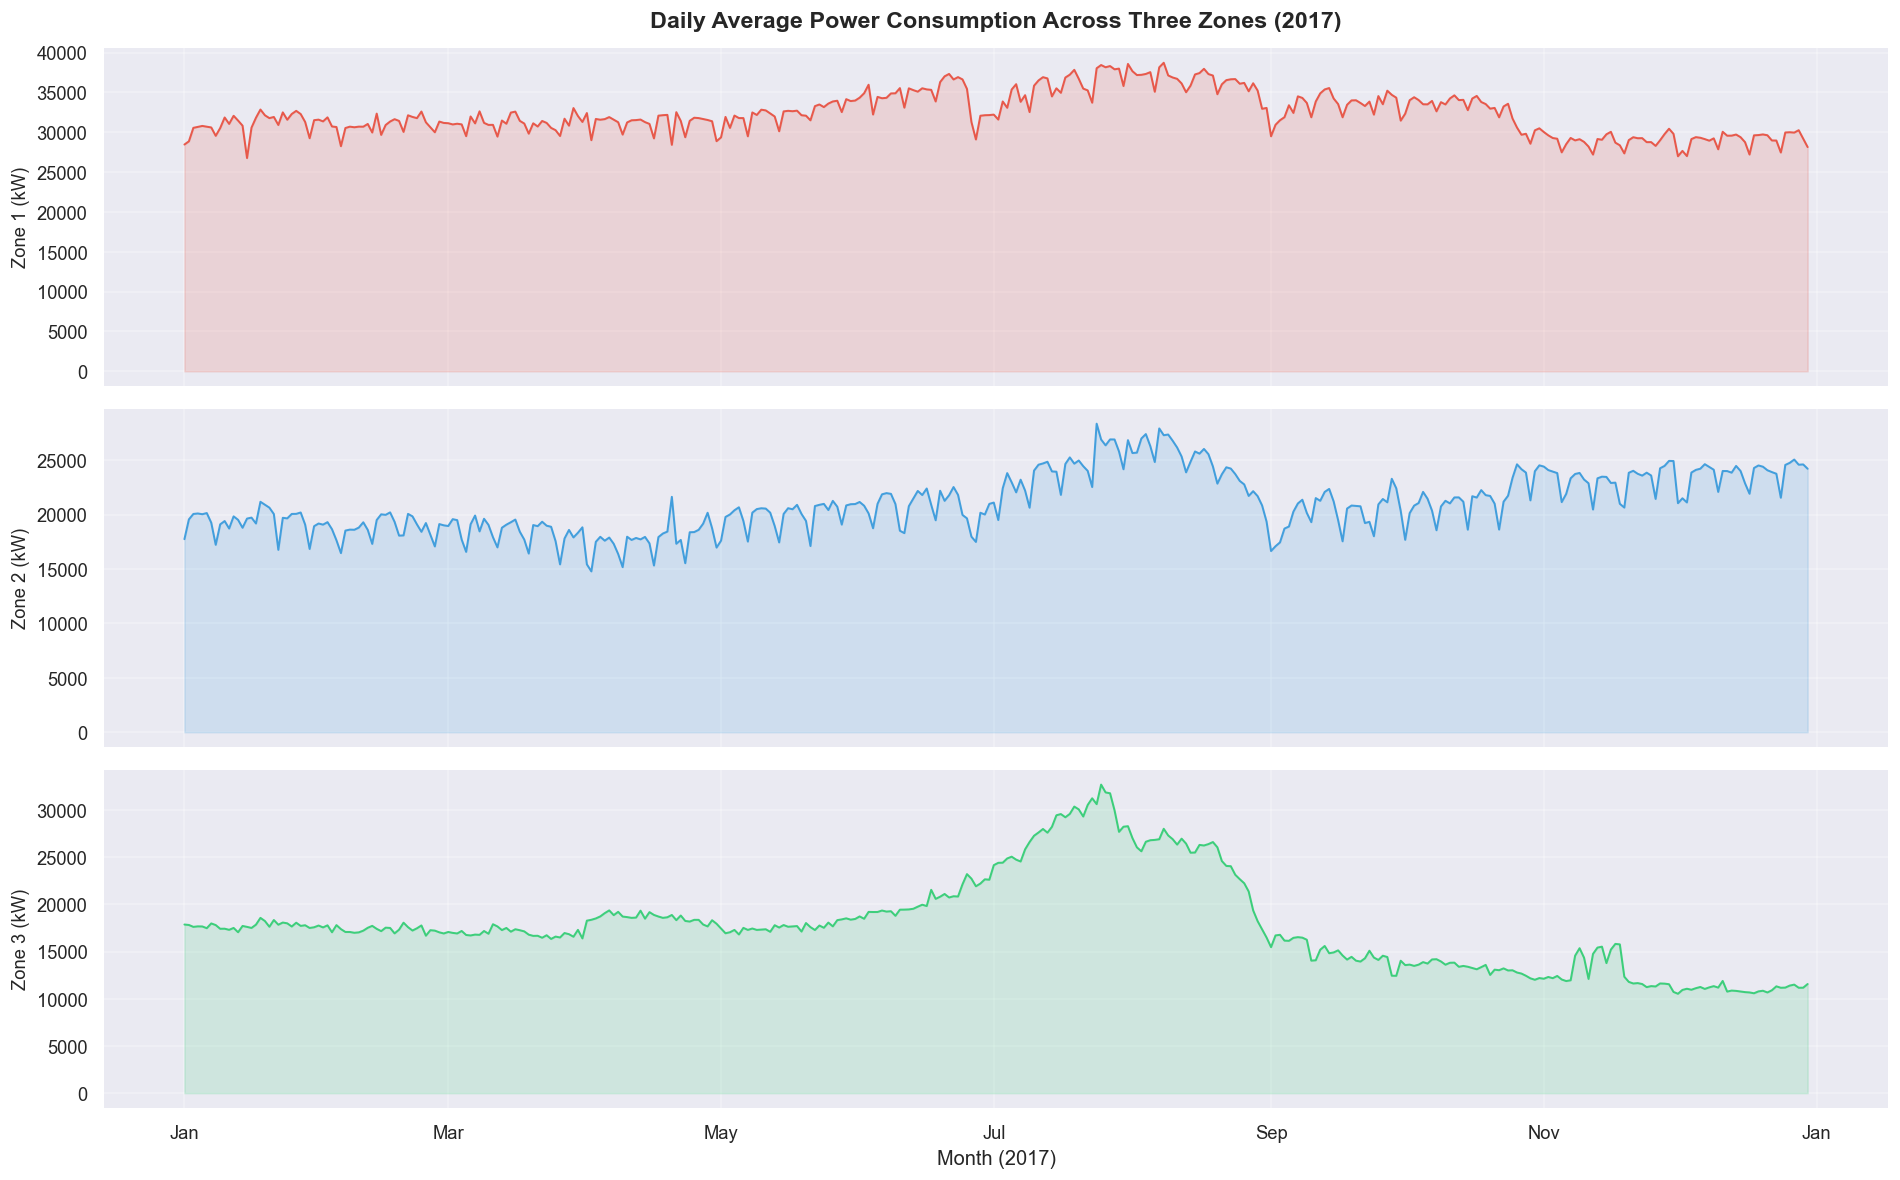

In [6]:
zones  = ['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
colors = ['#E74C3C', '#3498DB', '#2ECC71']
labels = ['Zone 1', 'Zone 2', 'Zone 3']

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for ax, zone, color, label in zip(axes, zones, colors, labels):
    daily = df.set_index('Datetime')[zone].resample('D').mean()
    ax.plot(daily.index, daily.values, color=color, linewidth=1.2, alpha=0.9)
    ax.fill_between(daily.index, daily.values, alpha=0.15, color=color)
    ax.set_ylabel(label + ' (kW)', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.grid(True, alpha=0.3)
axes[0].set_title('Daily Average Power Consumption Across Three Zones (2017)', fontsize=14, fontweight='bold', pad=12)
axes[-1].set_xlabel('Month (2017)', fontsize=12)
plt.tight_layout()
plt.show()


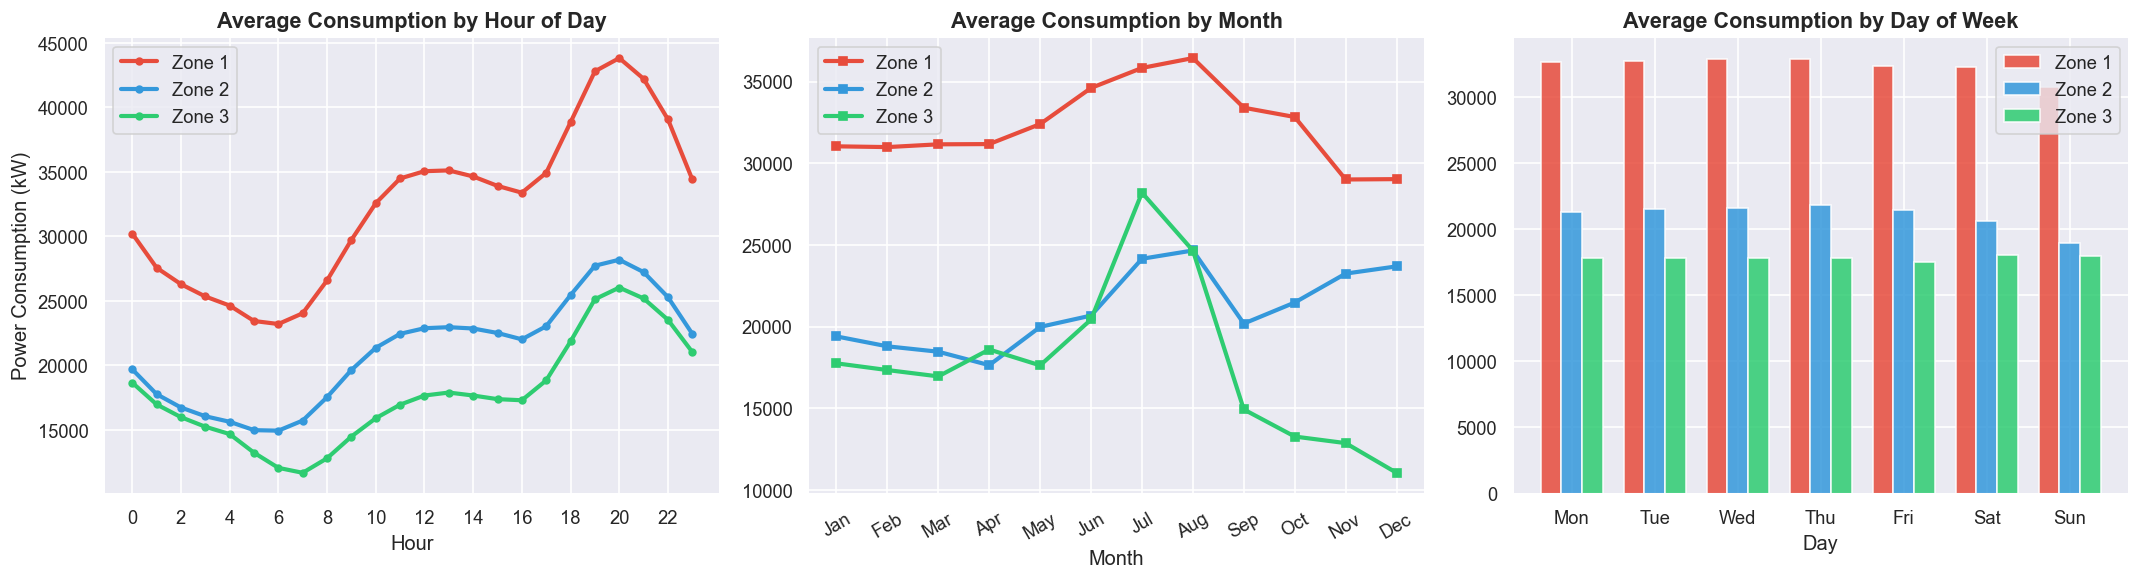

In [7]:
df['Hour']      = df['Datetime'].dt.hour
df['Month_raw'] = df['Datetime'].dt.month
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly_avg = df.groupby('Hour')[zones].mean()
for zone, color, label in zip(zones, colors, labels):
    axes[0].plot(hourly_avg.index, hourly_avg[zone], color=color, linewidth=2.5, label=label, marker='o', markersize=4)
axes[0].set_title('Average Consumption by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Power Consumption (kW)')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

monthly_avg = df.groupby('Month_raw')[zones].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for zone, color, label in zip(zones, colors, labels):
    axes[1].plot(monthly_avg.index, monthly_avg[zone], color=color, linewidth=2.5, label=label, marker='s', markersize=5)
axes[1].set_title('Average Consumption by Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels, rotation=30)
axes[1].legend()

dow_avg    = df.groupby('DayOfWeek')[zones].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
x = np.arange(7)
width = 0.25
for i, (zone, color, label) in enumerate(zip(zones, colors, labels)):
    axes[2].bar(x + i * width, dow_avg[zone], width, label=label, color=color, alpha=0.85)
axes[2].set_title('Average Consumption by Day of Week', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Day')
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(dow_labels)
axes[2].legend()

plt.tight_layout()
plt.show()


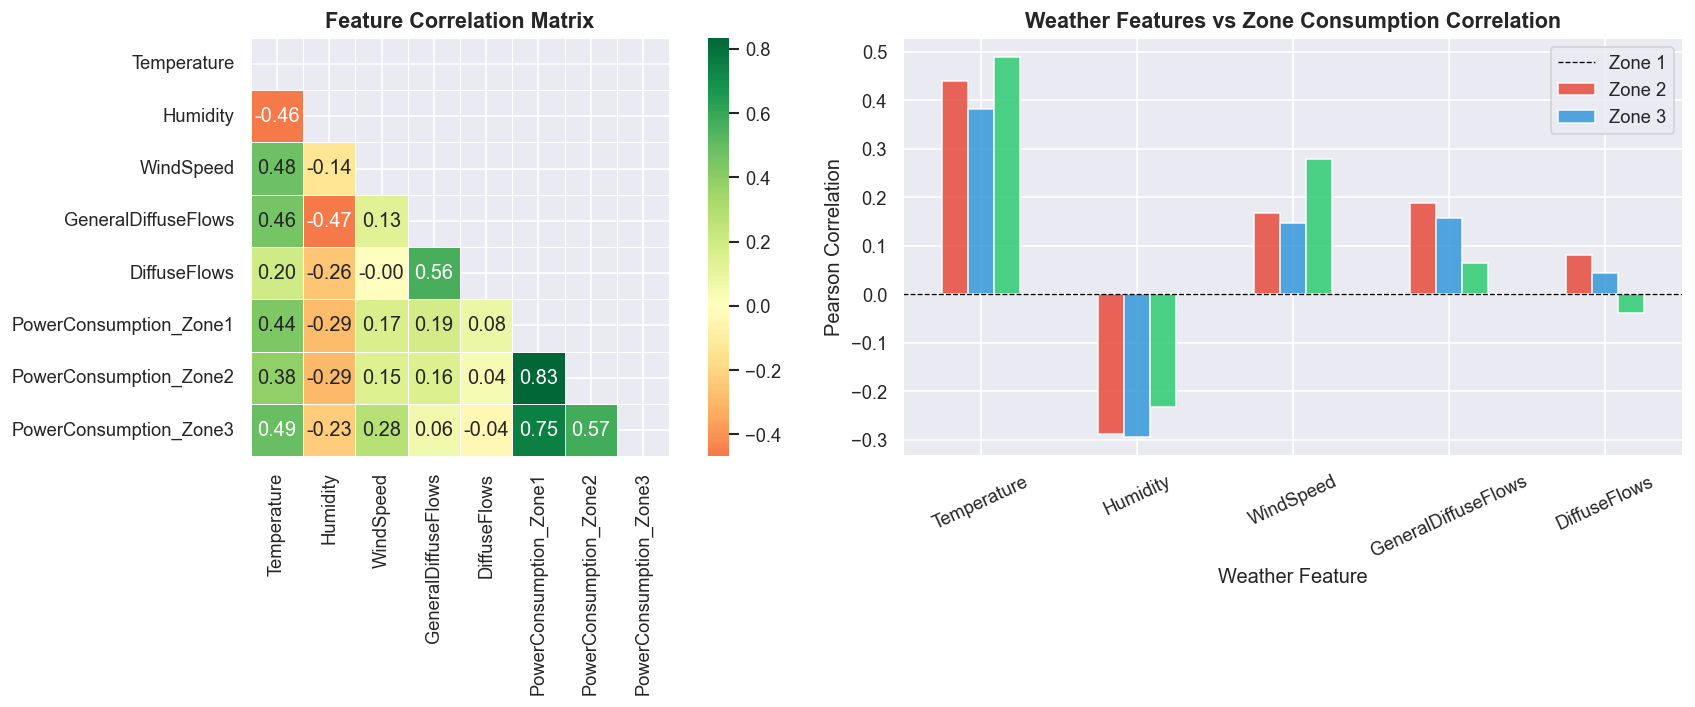

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df.drop(columns=['Datetime', 'Hour', 'Month_raw', 'DayOfWeek']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

weather_features = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']
corr_with_zones = df[weather_features + zones].corr()[zones].loc[weather_features]
corr_with_zones.plot(kind='bar', ax=axes[1], color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Weather Features vs Zone Consumption Correlation', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weather Feature')
axes[1].set_ylabel('Pearson Correlation')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticklabels(weather_features, rotation=25)
axes[1].legend(['Zone 1', 'Zone 2', 'Zone 3'])

plt.tight_layout()
plt.show()


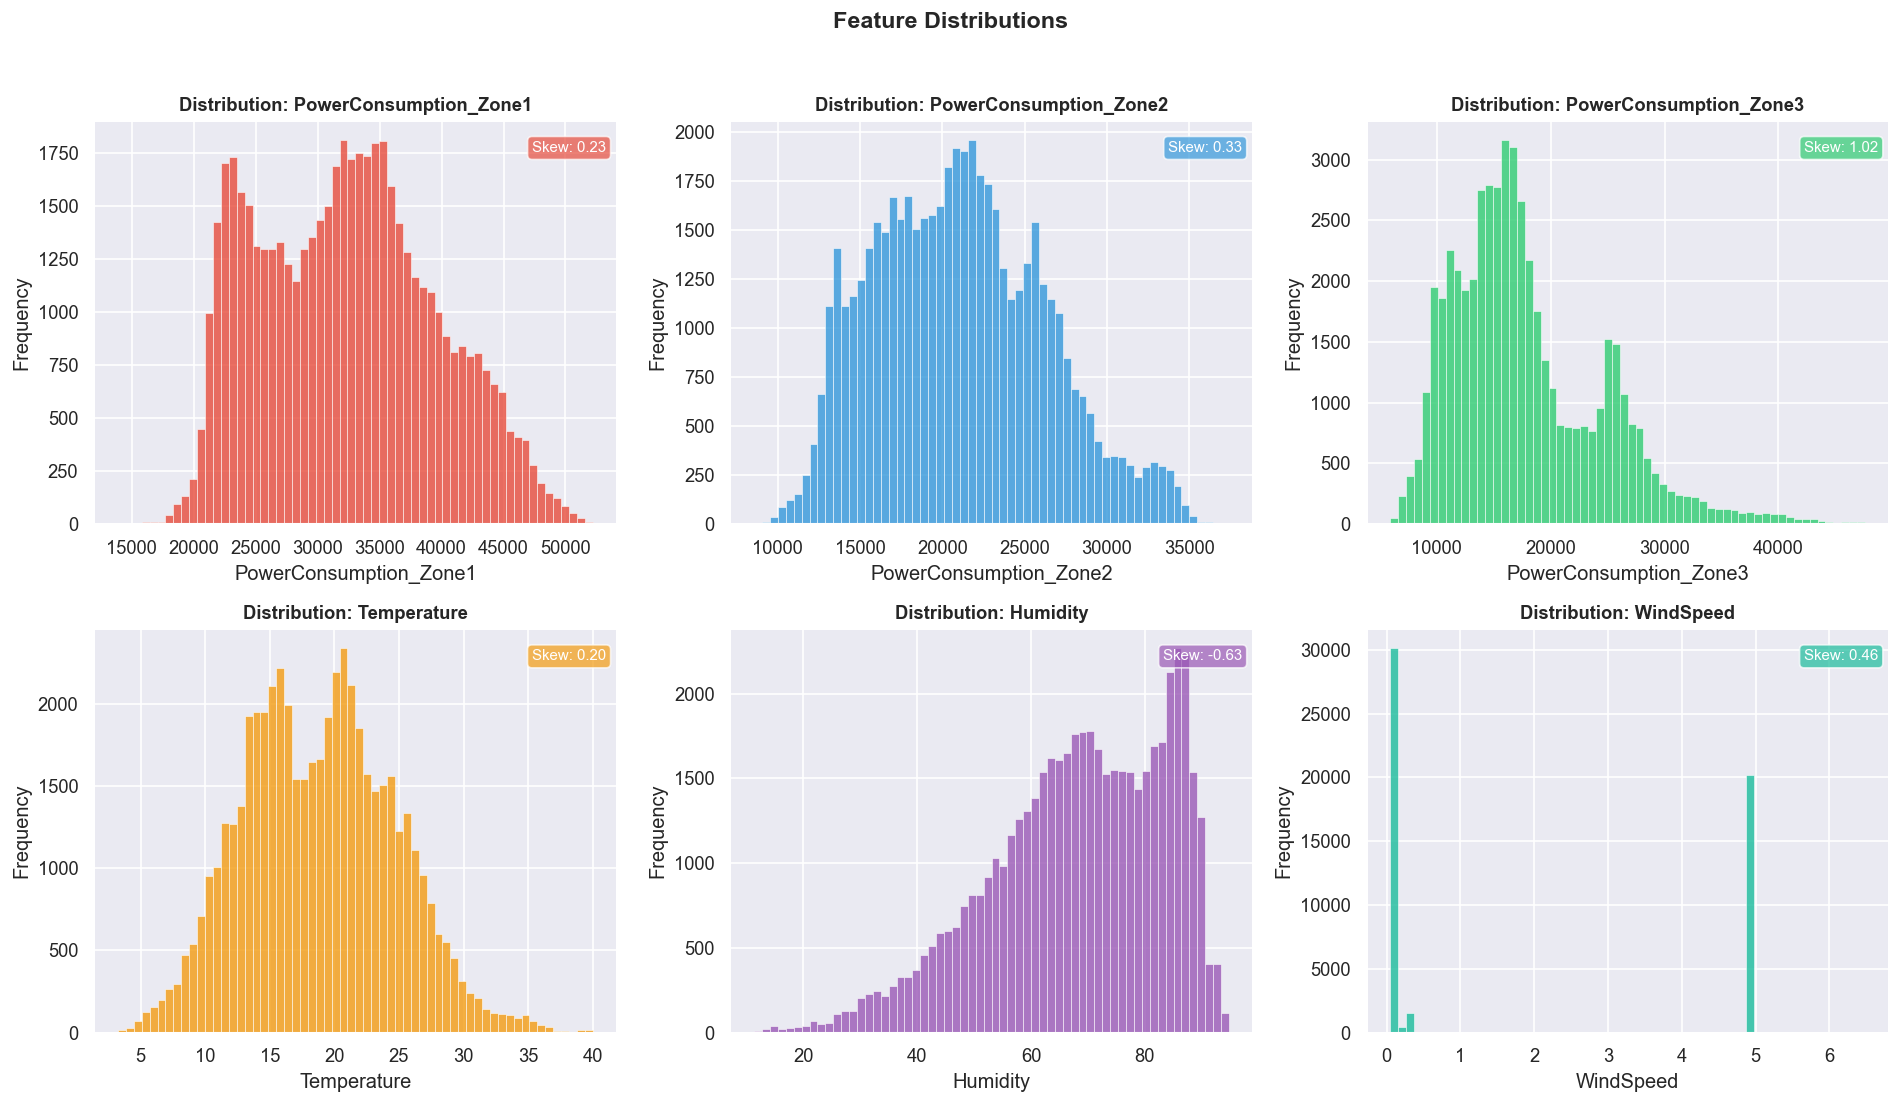

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

all_cols = zones + ['Temperature', 'Humidity', 'WindSpeed']
palette  = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']

for ax, col, color in zip(axes.flat, all_cols, palette):
    ax.hist(df[col], bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_title('Distribution: ' + col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    skew_val = df[col].skew()
    ax.text(0.98, 0.95, f'Skew: {skew_val:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='white',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


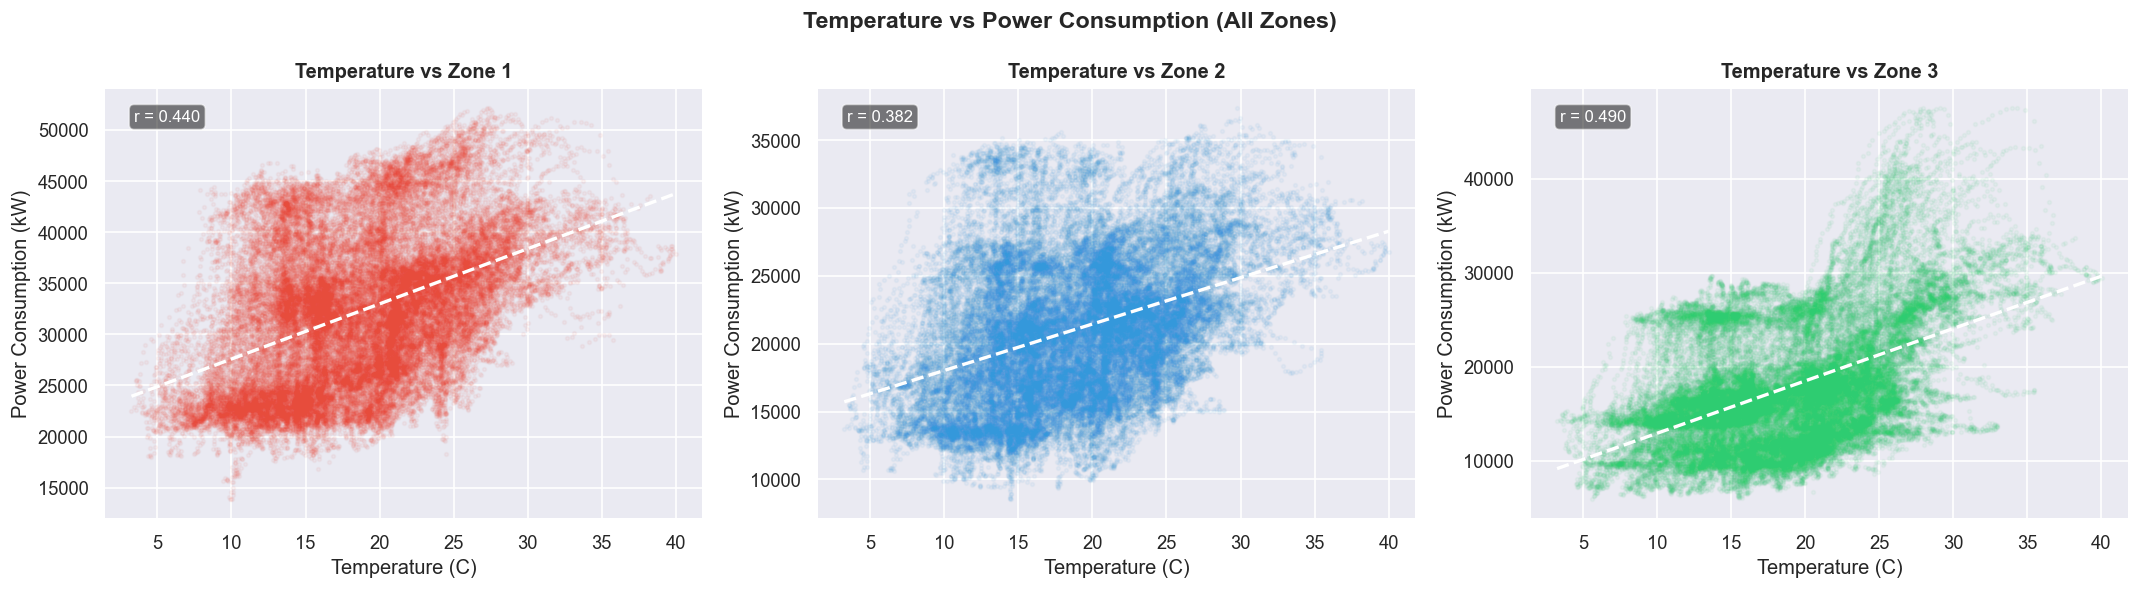

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, zone, color, label in zip(axes, zones, colors, labels):
    ax.scatter(df['Temperature'], df[zone], alpha=0.05, s=5, color=color)
    z = np.polyfit(df['Temperature'], df[zone], 1)
    p = np.poly1d(z)
    temp_range = np.linspace(df['Temperature'].min(), df['Temperature'].max(), 200)
    ax.plot(temp_range, p(temp_range), color='white', linewidth=2, linestyle='--', label='Trend')
    ax.set_title('Temperature vs ' + label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Temperature (C)')
    ax.set_ylabel('Power Consumption (kW)')
    corr = df['Temperature'].corr(df[zone])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=10, va='top', color='white',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

plt.suptitle('Temperature vs Power Consumption (All Zones)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


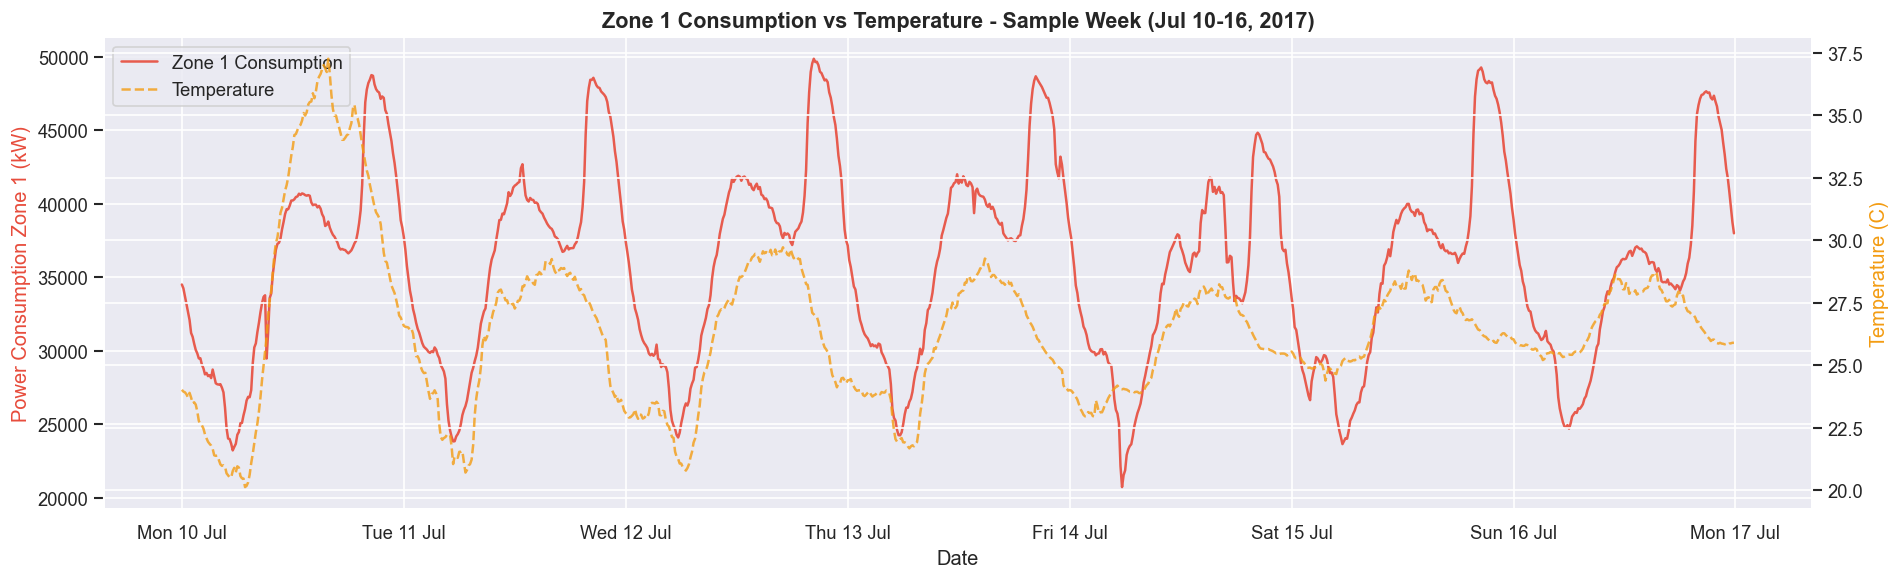

In [11]:
sample_week = df[(df['Datetime'] >= '2017-07-10') & (df['Datetime'] < '2017-07-17')]

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(sample_week['Datetime'], sample_week['PowerConsumption_Zone1'],
         color='#E74C3C', linewidth=1.5, label='Zone 1 Consumption', alpha=0.9)
ax2.plot(sample_week['Datetime'], sample_week['Temperature'],
         color='#F39C12', linewidth=1.5, linestyle='--', label='Temperature', alpha=0.8)

ax1.set_xlabel('Date')
ax1.set_ylabel('Power Consumption Zone 1 (kW)', color='#E74C3C')
ax2.set_ylabel('Temperature (C)', color='#F39C12')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%a %d %b'))
plt.xticks(rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Zone 1 Consumption vs Temperature - Sample Week (Jul 10-16, 2017)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Feature Engineering


In [12]:
df['DayOfYear']  = df['Datetime'].dt.dayofyear
df['WeekOfYear'] = df['Datetime'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['Datetime'].dt.quarter
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

df['Hour_sin']      = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos']      = np.cos(2 * np.pi * df['Hour'] / 24)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin']     = np.sin(2 * np.pi * df['Month_raw'] / 12)
df['Month_cos']     = np.cos(2 * np.pi * df['Month_raw'] / 12)

def get_season(month):
    if month in [12, 1, 2]:
        return 0
    elif month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    else:
        return 3

df['Season']          = df['Month_raw'].apply(get_season)
df['Temp_Humidity']   = df['Temperature'] * df['Humidity']
df['TotalSolarFlow']  = df['GeneralDiffuseFlows'] + df['DiffuseFlows']
df['IsBusinessHour']  = ((df['Hour'] >= 8) & (df['Hour'] <= 18) & (df['IsWeekend'] == 0)).astype(int)

LAG_STEPS    = [1, 6, 12, 24, 48]
ROLL_WINDOWS = [6, 12, 24]

for lag in LAG_STEPS:
    for zone in zones:
        df[zone + '_lag' + str(lag)] = df[zone].shift(lag)

for win in ROLL_WINDOWS:
    for zone in zones:
        df[zone + '_roll_mean' + str(win)] = df[zone].shift(1).rolling(window=win).mean()
        df[zone + '_roll_std'  + str(win)] = df[zone].shift(1).rolling(window=win).std()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Dataset shape after feature engineering:', df.shape)
print('Total columns:', df.shape[1])


Dataset shape after feature engineering: (52368, 59)
Total columns: 59


---
## Train / Test Split


In [13]:
exclude_cols = ['Datetime'] + zones
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df[zones]

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test      = df['Datetime'].iloc[split_idx:]

n_train = X_train.shape[0]
n_test  = X_test.shape[0]
n_total = len(df)

print('Training set :', n_train, 'samples  (', round(n_train / n_total * 100, 1), '%)')
print('Test set     :', n_test,  'samples  (', round(n_test  / n_total * 100, 1), '%)')
print('Train period :', df['Datetime'].iloc[0].date(), 'to', df['Datetime'].iloc[split_idx - 1].date())
print('Test period  :', df['Datetime'].iloc[split_idx].date(), 'to', df['Datetime'].iloc[-1].date())

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('\nFeatures standardized successfully.')


Training set : 41894 samples  ( 80.0 %)
Test set     : 10474 samples  ( 20.0 %)
Train period : 2017-01-01 to 2017-10-19
Test period  : 2017-10-19 to 2017-12-30

Features standardized successfully.


---
## Model Selection, Training & Evaluation


In [14]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    results = {}
    for zone in zones:
        model.fit(X_tr, y_tr[zone])
        preds = model.predict(X_te)
        results[zone] = {
            'RMSE'        : np.sqrt(mean_squared_error(y_te[zone], preds)),
            'MAE'         : mean_absolute_error(y_te[zone], preds),
            'R2'          : r2_score(y_te[zone], preds),
            'Predictions' : preds
        }
    return results

models_config = {
    'Linear Regression' : (LinearRegression(), True),
    'Ridge Regression'  : (Ridge(alpha=1.0), True),
    'Random Forest'     : (RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1), False),
    'XGBoost'           : (XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                                         subsample=0.8, colsample_bytree=0.8,
                                         random_state=SEED, n_jobs=-1, verbosity=0), False),
}

all_results = {}
for model_name, (model, use_scaled) in models_config.items():
    print('Training:', model_name, '...')
    Xtr = X_train_sc if use_scaled else X_train.values
    Xte = X_test_sc  if use_scaled else X_test.values
    all_results[model_name] = evaluate_model(model, Xtr, Xte, y_train, y_test)
    print('  Done.')
print('\nAll models trained.')


Training: Linear Regression ...
  Done.
Training: Ridge Regression ...
  Done.
Training: Random Forest ...
  Done.
Training: XGBoost ...
  Done.

All models trained.


In [15]:
summary_rows = []
for model_name, zone_results in all_results.items():
    for zone, metrics in zone_results.items():
        summary_rows.append({
            'Model' : model_name,
            'Zone'  : zone.replace('PowerConsumption_', ''),
            'RMSE'  : round(metrics['RMSE'], 2),
            'MAE'   : round(metrics['MAE'],  2),
            'R2'    : round(metrics['R2'],   4),
        })

summary_df = pd.DataFrame(summary_rows)
print('=== R2 Score (higher is better) ===')
print(summary_df.pivot(index='Model', columns='Zone', values='R2').to_string())
print('\n=== RMSE (lower is better) ===')
print(summary_df.pivot(index='Model', columns='Zone', values='RMSE').to_string())


=== R2 Score (higher is better) ===
Zone                Zone1   Zone2   Zone3
Model                                    
Linear Regression  0.9964  0.9969  0.9929
Random Forest      0.9934  0.9943  0.9819
Ridge Regression   0.9963  0.9969  0.9929
XGBoost            0.9930  0.9951  0.9798

=== RMSE (lower is better) ===
Zone                Zone1   Zone2   Zone3
Model                                    
Linear Regression  372.41  303.78  277.35
Random Forest      502.32  415.57  443.50
Ridge Regression   374.51  304.46  277.49
XGBoost            514.90  384.44  469.06


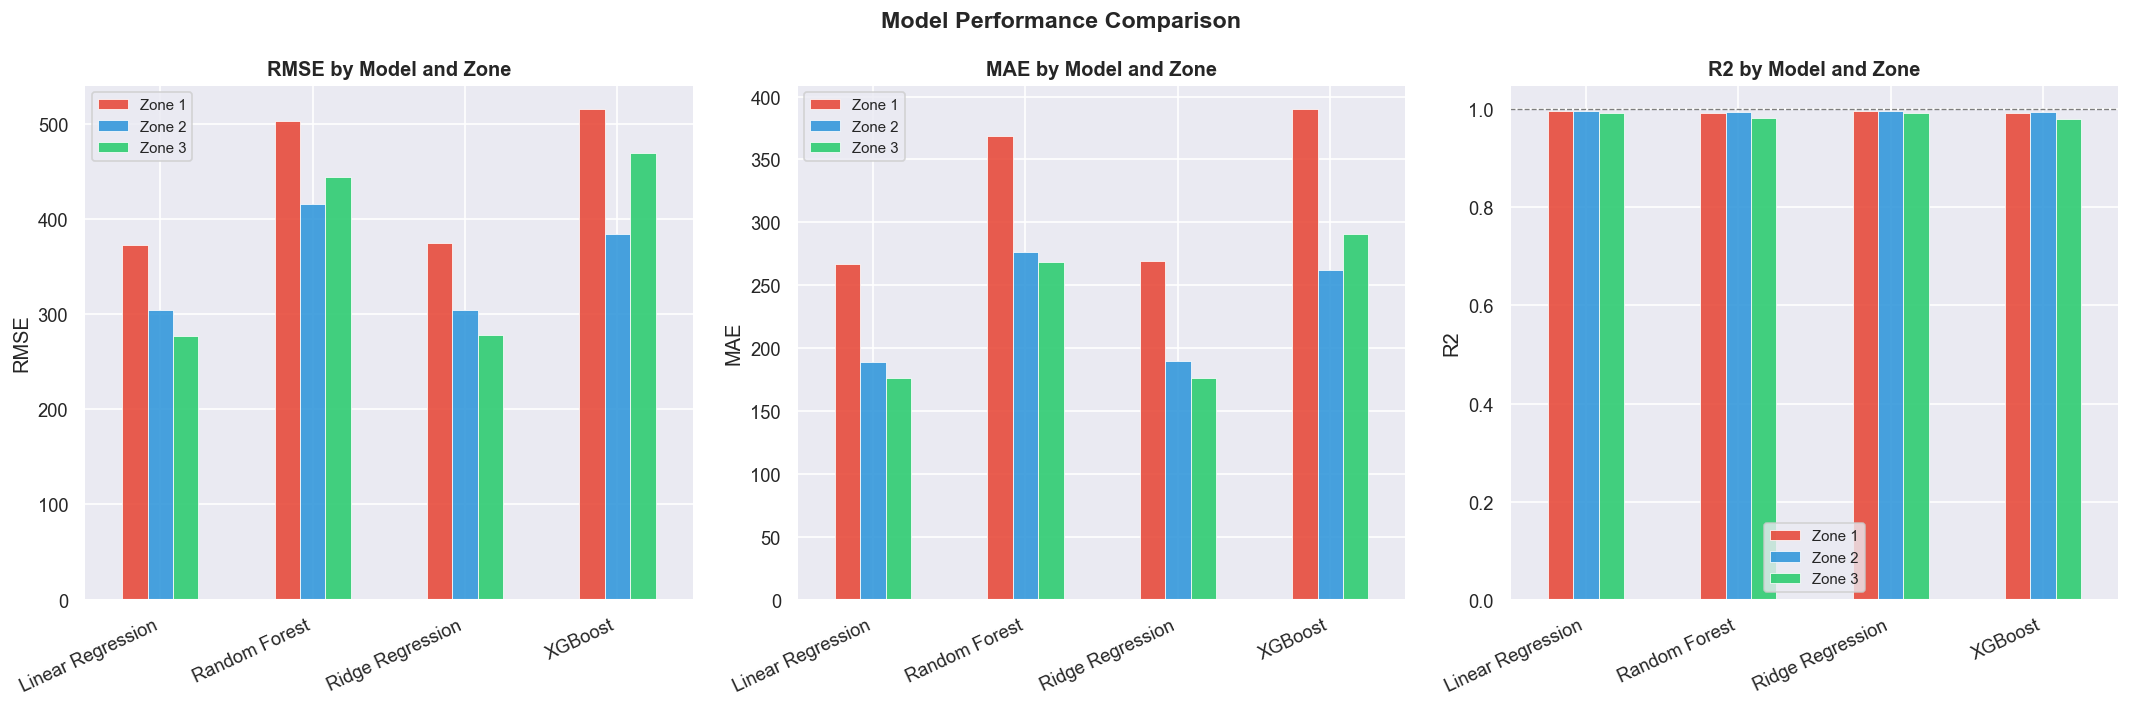

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metric_names = ['RMSE', 'MAE', 'R2']

for ax, metric in zip(axes, metric_names):
    pivot = summary_df.pivot(index='Model', columns='Zone', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#E74C3C', '#3498DB', '#2ECC71'],
               edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.set_title(metric + ' by Model and Zone', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.legend(['Zone 1', 'Zone 2', 'Zone 3'], fontsize=9)
    if metric == 'R2':
        ax.set_ylim(0, 1.05)
        ax.axhline(1.0, linestyle='--', color='black', linewidth=0.8, alpha=0.5)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


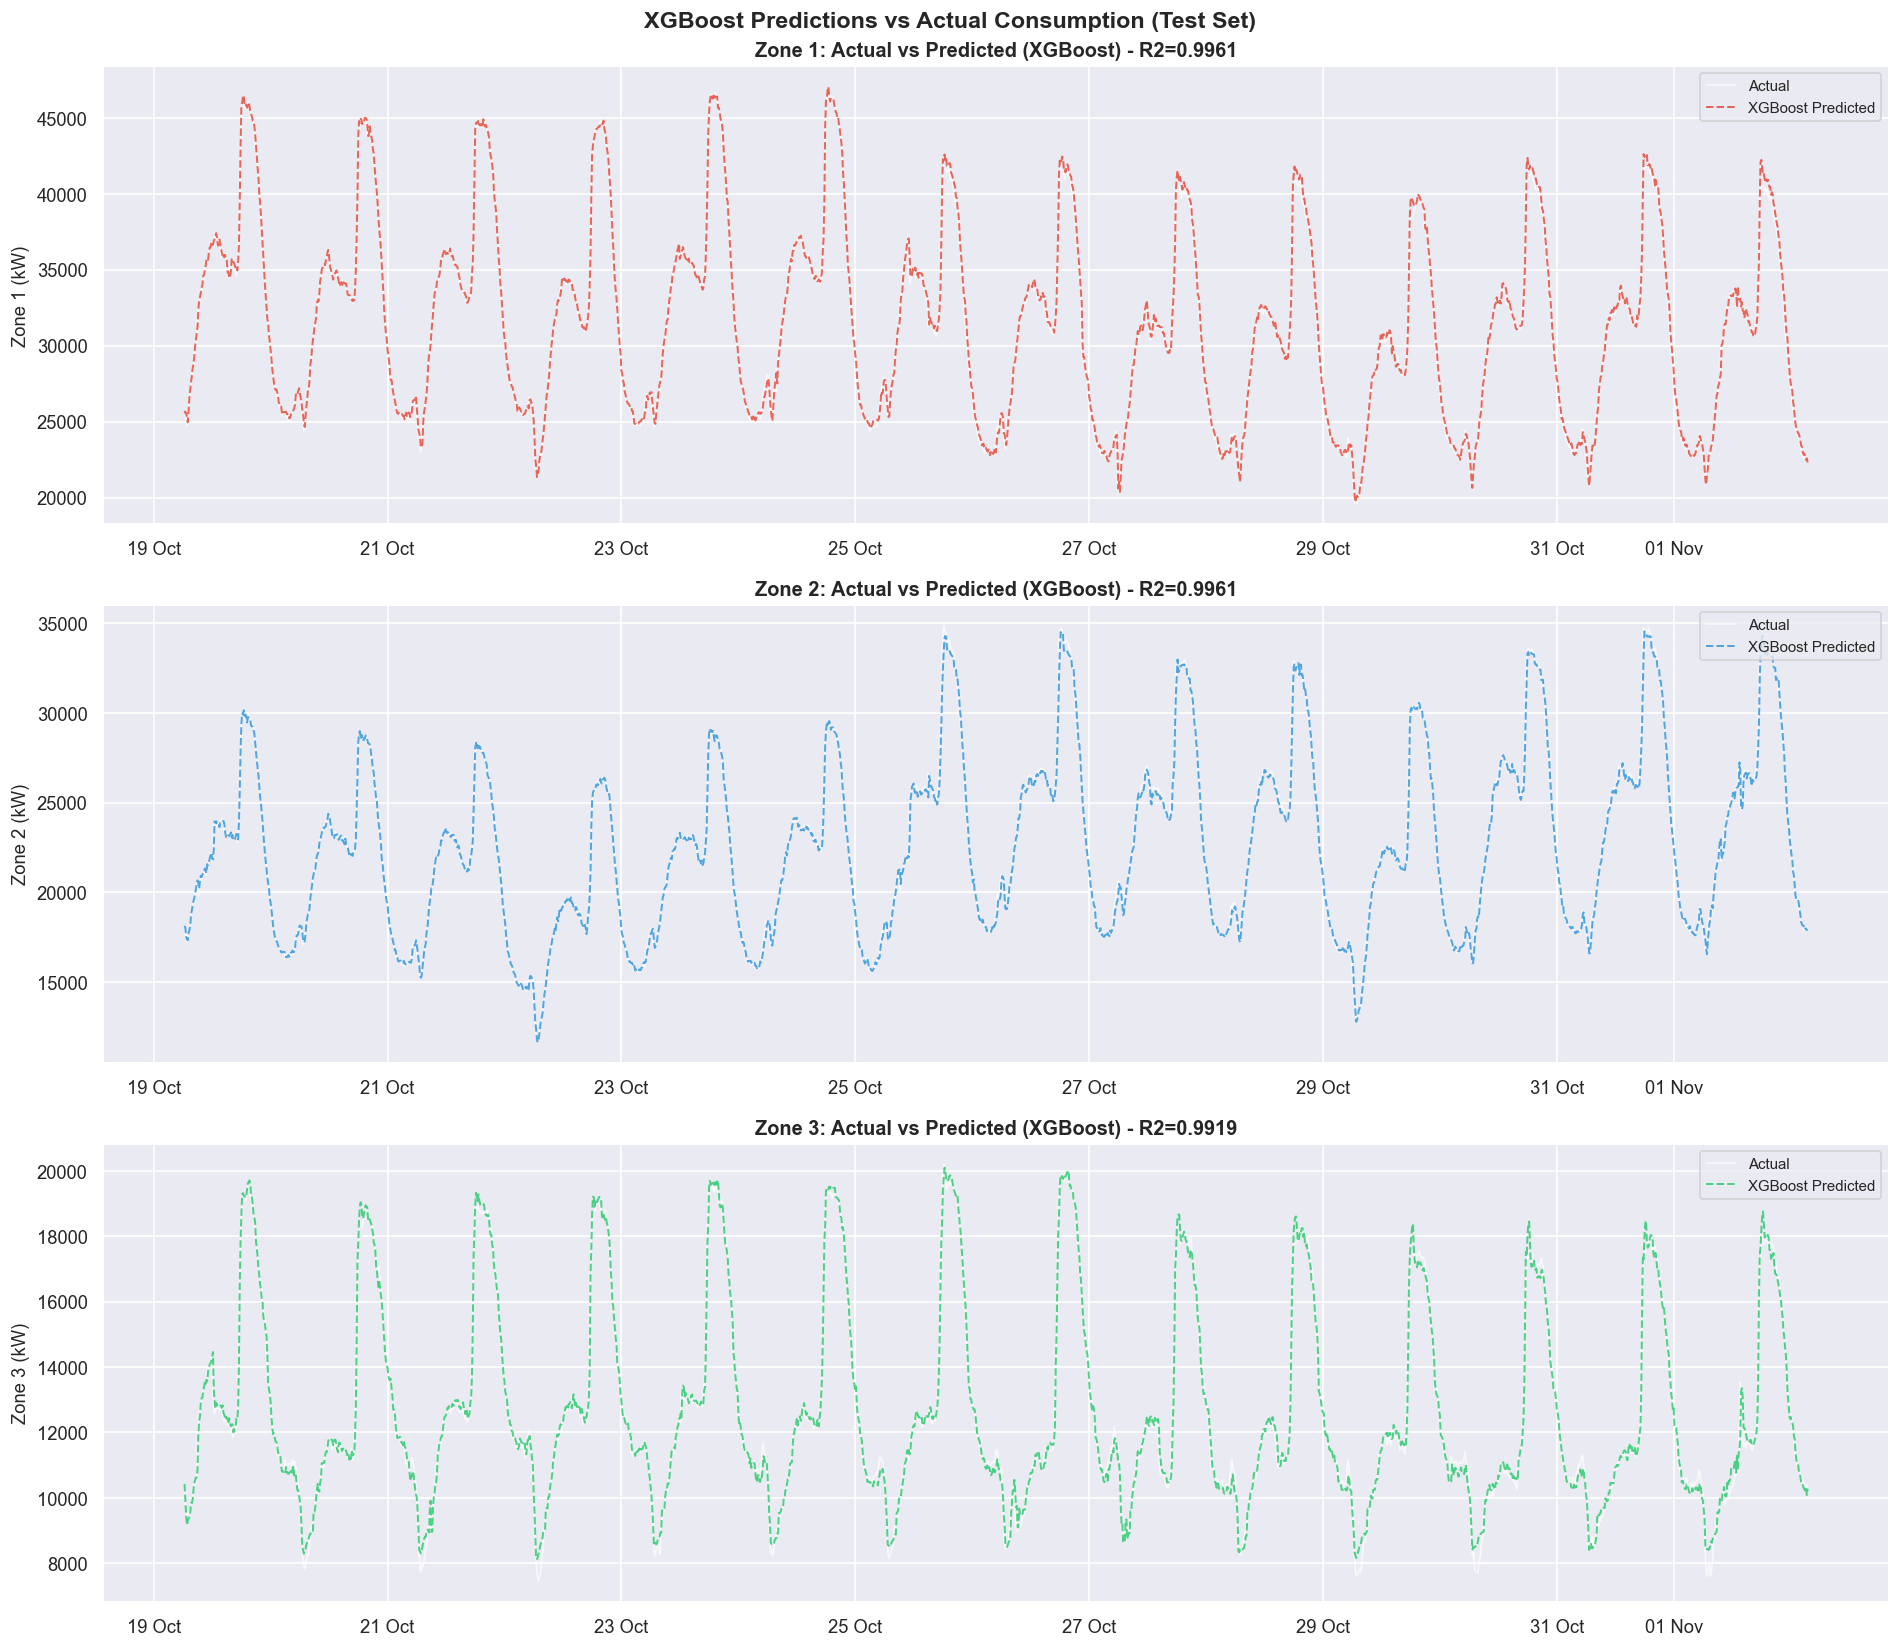

In [17]:
xgb_base = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=SEED, n_jobs=-1, verbosity=0)

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for ax, zone, color, label in zip(axes, zones, colors, labels):
    xgb_base.fit(X_train.values, y_train[zone])
    preds  = xgb_base.predict(X_test.values)
    plot_n = min(2000, len(preds))
    ax.plot(dates_test.values[:plot_n], y_test[zone].values[:plot_n],
            color='white', linewidth=1.0, alpha=0.7, label='Actual')
    ax.plot(dates_test.values[:plot_n], preds[:plot_n],
            color=color, linewidth=1.2, alpha=0.85, linestyle='--', label='XGBoost Predicted')
    ax.set_ylabel(label + ' (kW)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    r2 = r2_score(y_test[zone].values[:plot_n], preds[:plot_n])
    ax.set_title(label + ': Actual vs Predicted (XGBoost) - R2=' + str(round(r2, 4)),
                 fontsize=12, fontweight='bold')

plt.suptitle('XGBoost Predictions vs Actual Consumption (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
##  Hyperparameter Tuning (XGBoost)


In [18]:
param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5],
}

xgb_cv = XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0)
random_search = RandomizedSearchCV(
    xgb_cv, param_dist, n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=-1, verbose=1
)
random_search.fit(X_train.values, y_train['PowerConsumption_Zone1'])

print('Best Parameters (Zone 1):')
for k, v in random_search.best_params_.items():
    print(' ', k, ':', v)
print('\nBest CV RMSE:', round(-random_search.best_score_, 2))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters (Zone 1):
  subsample : 0.9
  n_estimators : 100
  min_child_weight : 5
  max_depth : 4
  learning_rate : 0.05
  colsample_bytree : 1.0

Best CV RMSE: 529.16


In [20]:
xgb_final = {}
for zone in zones:
    model = XGBRegressor(**random_search.best_params_, random_state=SEED, n_jobs=-1, verbosity=0)
    model.fit(X_train.values, y_train[zone])
    preds = model.predict(X_test.values)
    xgb_final[zone] = {
        'model'       : model,
        'predictions' : preds,
        'RMSE'        : np.sqrt(mean_squared_error(y_test[zone], preds)),
        'MAE'         : mean_absolute_error(y_test[zone], preds),
        'R2'          : r2_score(y_test[zone], preds),
    }

print('=== Final Tuned XGBoost - Test Set Performance ===')
for zone, m in xgb_final.items():
    z = zone.replace('PowerConsumption_', '')
    print(z, ' RMSE:', round(m['RMSE'], 2), ' MAE:', round(m['MAE'], 2), ' R2:', round(m['R2'], 4))


=== Final Tuned XGBoost - Test Set Performance ===
Zone1  RMSE: 444.4  MAE: 327.98  R2: 0.9948
Zone2  RMSE: 379.04  MAE: 244.72  R2: 0.9952
Zone3  RMSE: 532.4  MAE: 335.0  R2: 0.974


---
## Visualization of Results


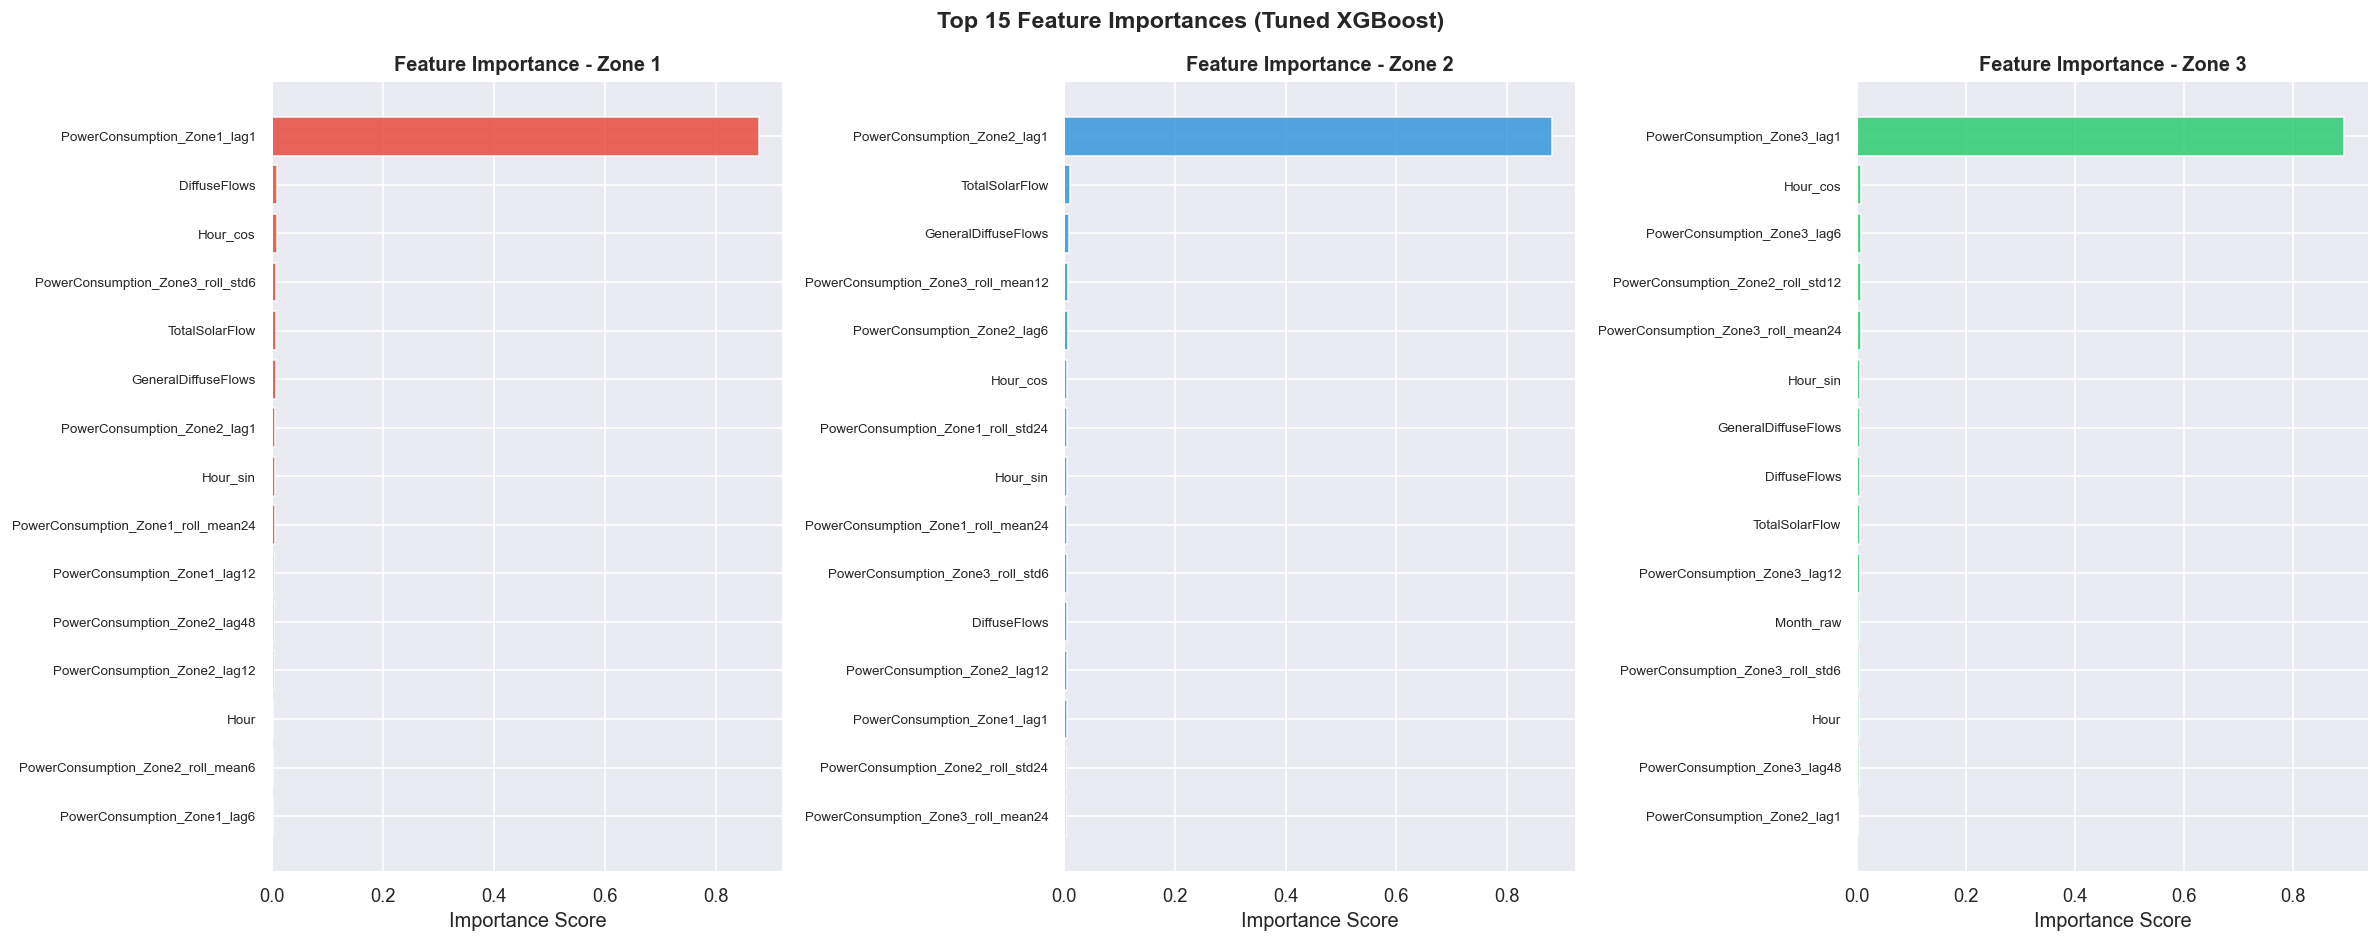

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, zone, color, label in zip(axes, zones, colors, labels):
    model = xgb_final[zone]['model']
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    top15 = importances.nlargest(15).sort_values()
    ax.barh(top15.index, top15.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title('Feature Importance - ' + label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 15 Feature Importances (Tuned XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


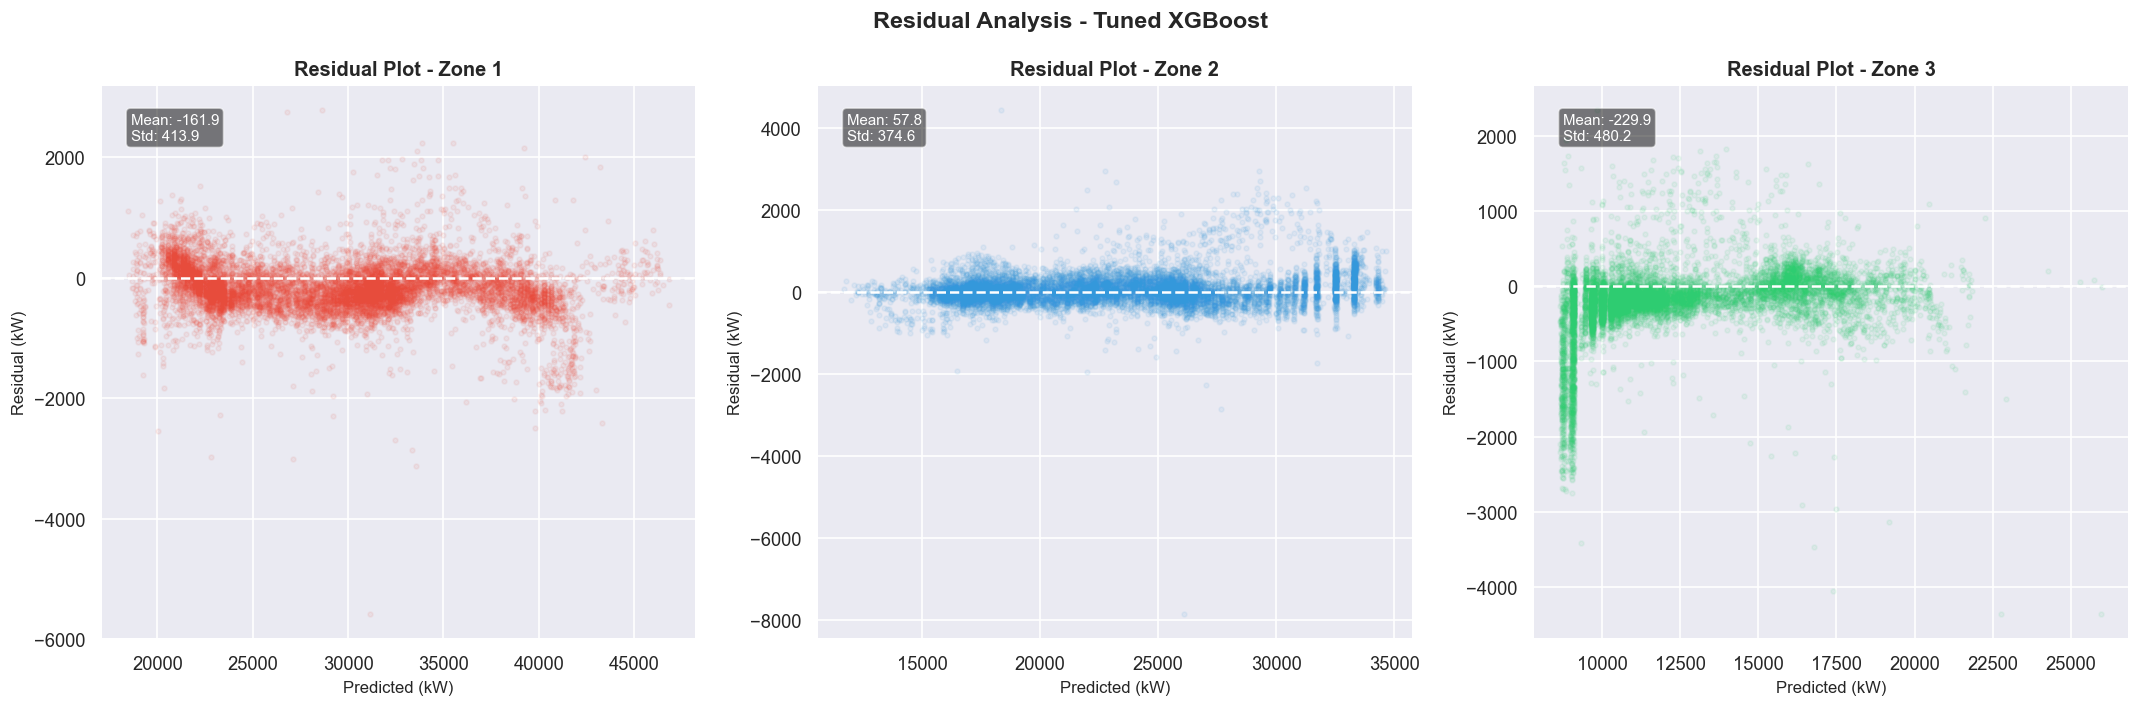

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, zone, color, label in zip(axes, zones, colors, labels):
    actual    = y_test[zone].values
    predicted = xgb_final[zone]['predictions']
    residuals = actual - predicted
    ax.scatter(predicted, residuals, alpha=0.08, s=8, color=color)
    ax.axhline(0, color='white', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted (kW)', fontsize=10)
    ax.set_ylabel('Residual (kW)', fontsize=10)
    ax.set_title('Residual Plot - ' + label, fontsize=12, fontweight='bold')
    ax.text(0.05, 0.95,
            'Mean: ' + str(round(residuals.mean(), 1)) + '\nStd: ' + str(round(residuals.std(), 1)),
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.5), color='white')

plt.suptitle('Residual Analysis - Tuned XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


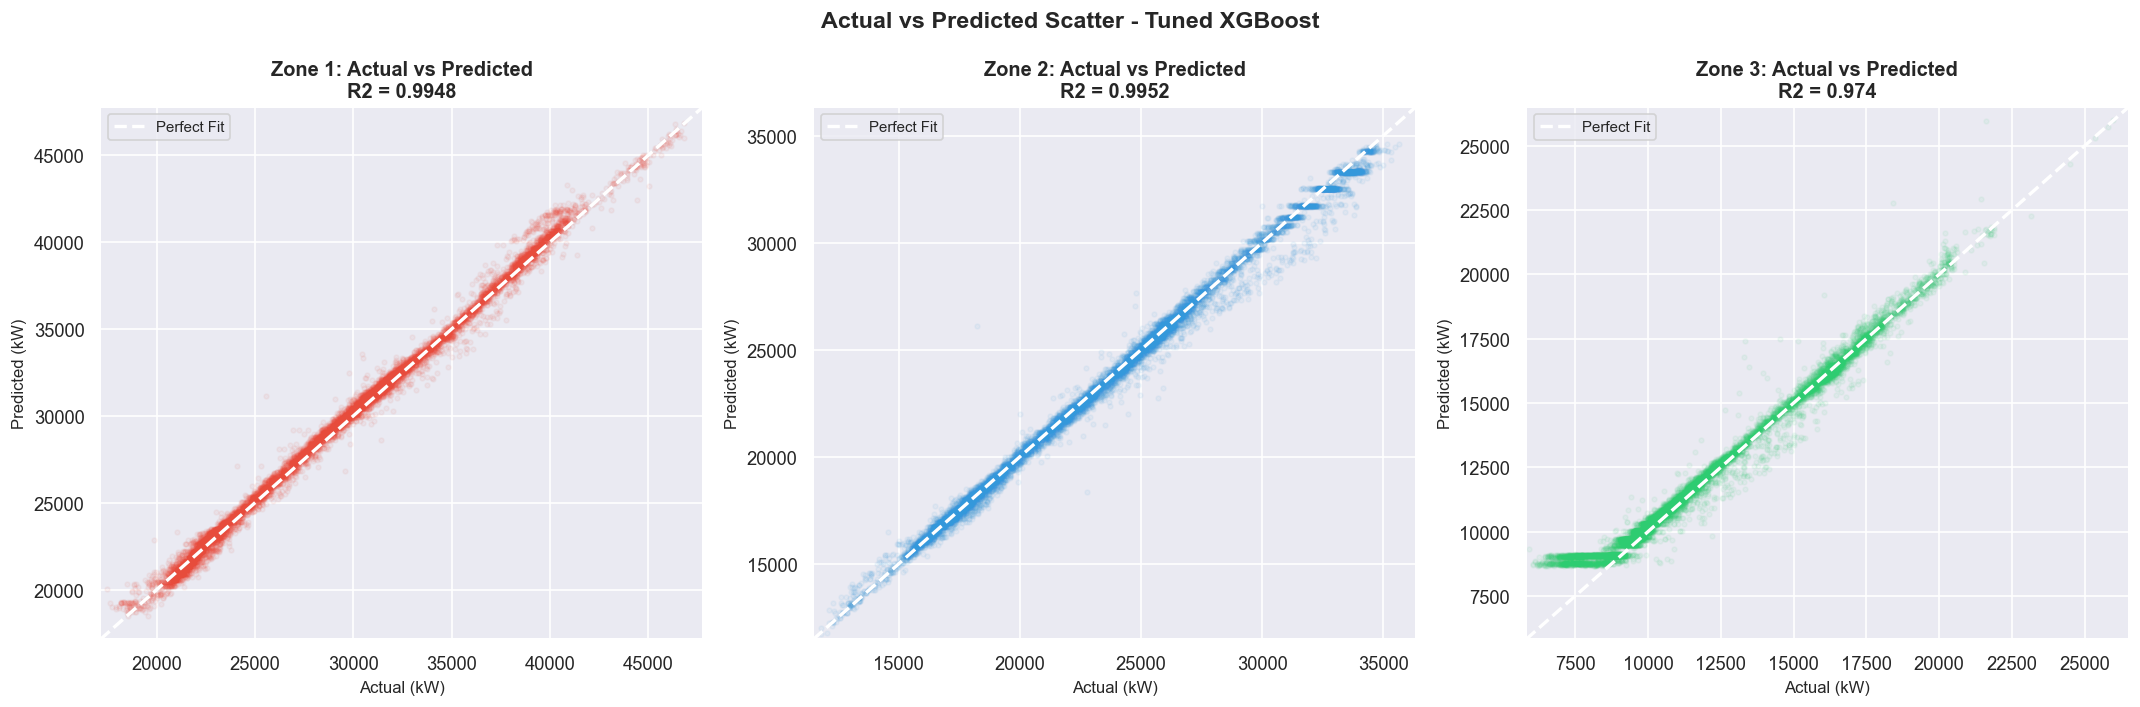

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, zone, color, label in zip(axes, zones, colors, labels):
    actual    = y_test[zone].values
    predicted = xgb_final[zone]['predictions']
    ax.scatter(actual, predicted, alpha=0.06, s=8, color=color)
    lim_min = min(actual.min(), predicted.min()) * 0.98
    lim_max = max(actual.max(), predicted.max()) * 1.02
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color='white', linewidth=2,
            linestyle='--', label='Perfect Fit')
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel('Actual (kW)', fontsize=10)
    ax.set_ylabel('Predicted (kW)', fontsize=10)
    r2 = xgb_final[zone]['R2']
    ax.set_title(label + ': Actual vs Predicted\nR2 = ' + str(round(r2, 4)),
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Scatter - Tuned XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


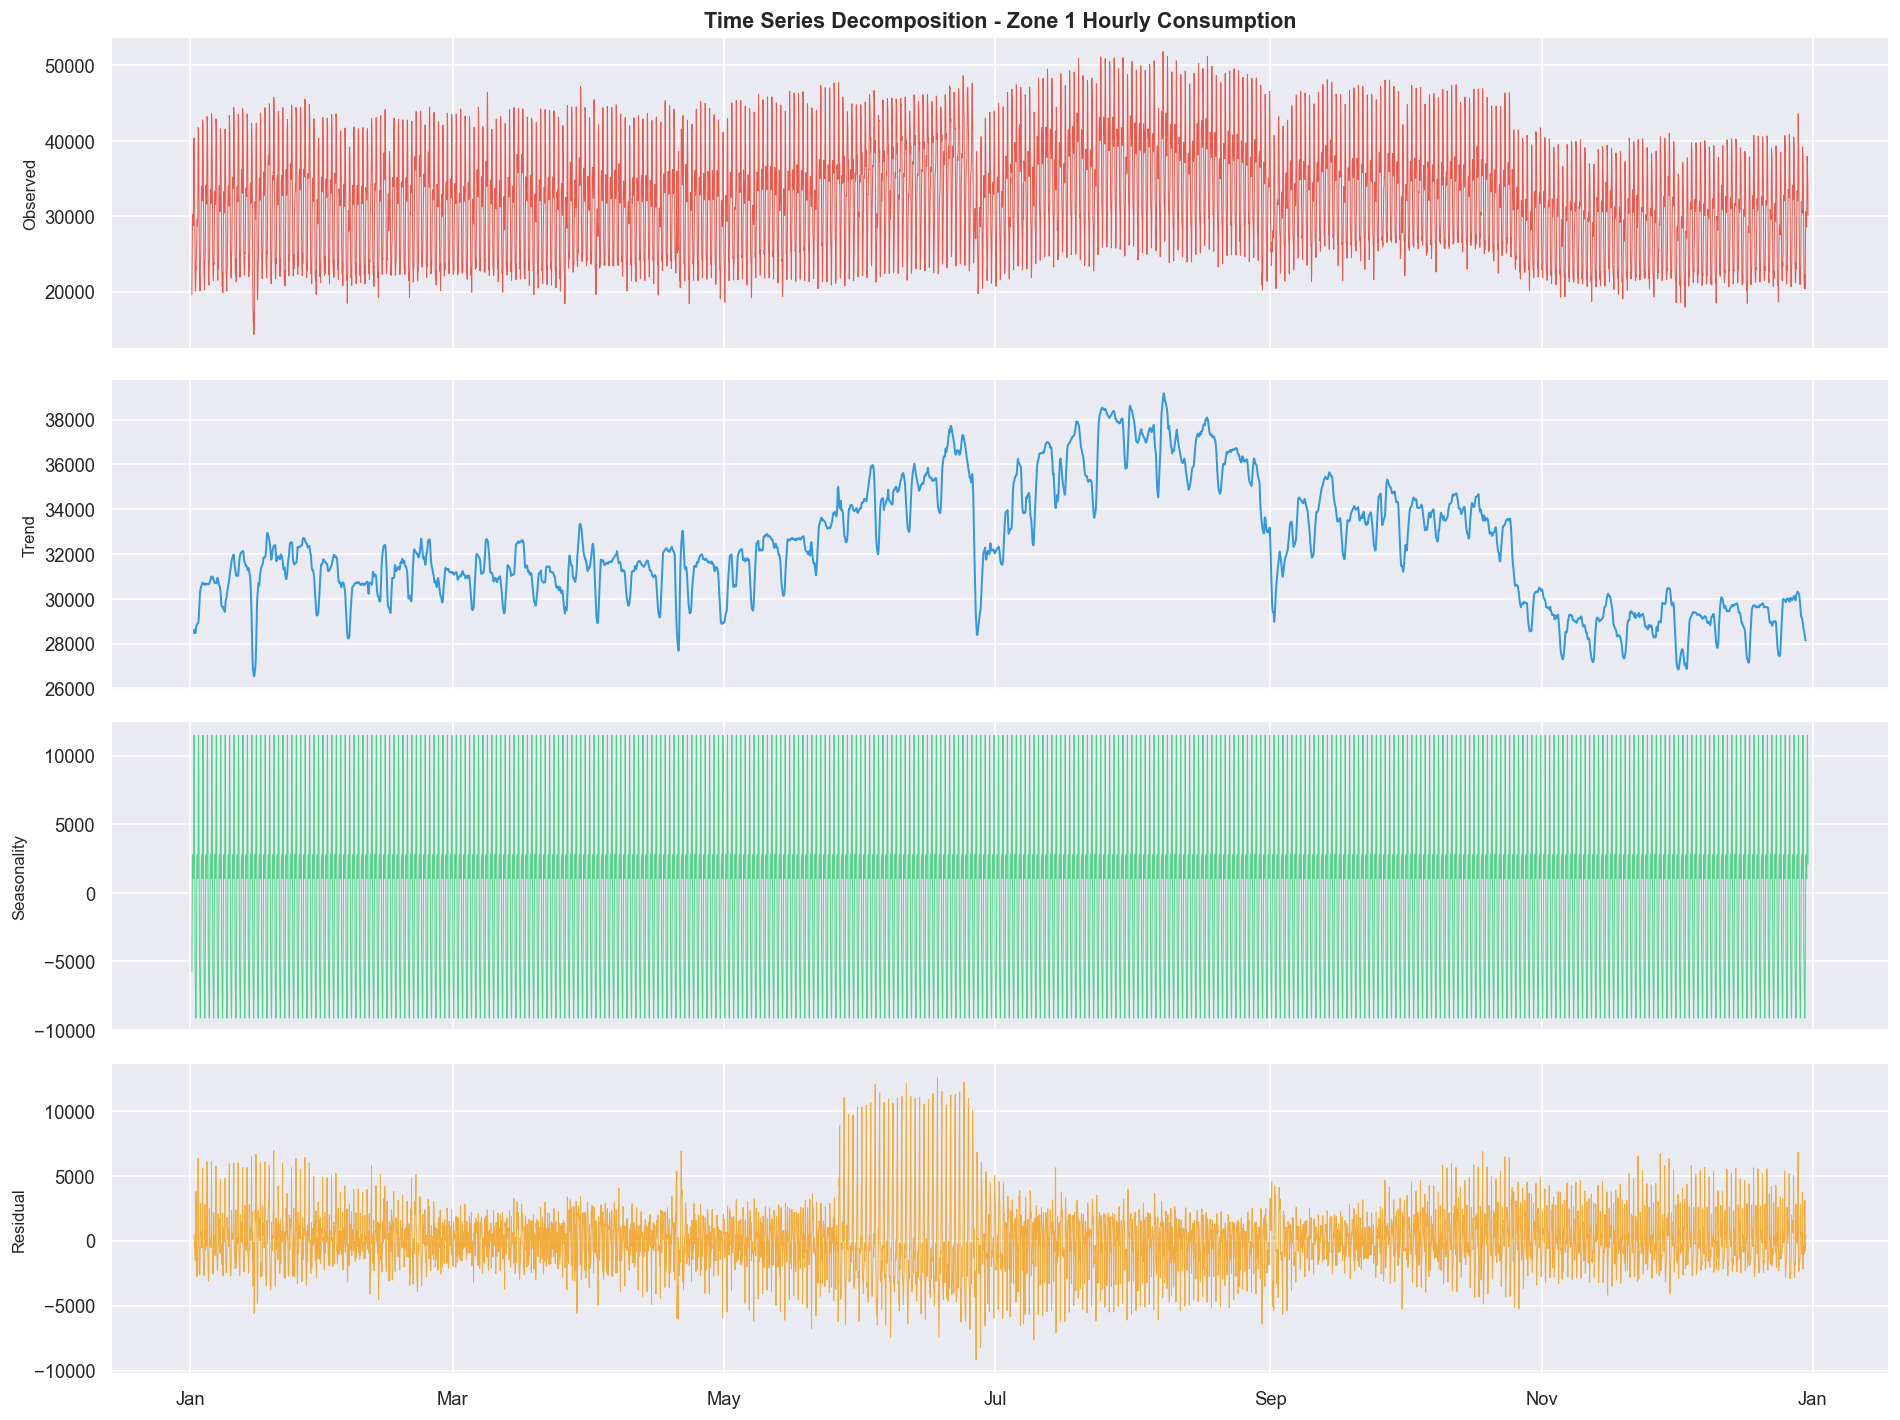

In [24]:
ts_daily = df.set_index('Datetime')['PowerConsumption_Zone1'].resample('H').mean().dropna()
decomposition = seasonal_decompose(ts_daily, model='additive', period=24)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

ax1.plot(decomposition.observed,  color='#E74C3C', linewidth=0.6, alpha=0.9)
ax1.set_ylabel('Observed', fontsize=10)
ax1.set_title('Time Series Decomposition - Zone 1 Hourly Consumption', fontsize=13, fontweight='bold')

ax2.plot(decomposition.trend,     color='#3498DB', linewidth=1.2)
ax2.set_ylabel('Trend', fontsize=10)

ax3.plot(decomposition.seasonal,  color='#2ECC71', linewidth=0.6, alpha=0.8)
ax3.set_ylabel('Seasonality', fontsize=10)

ax4.plot(decomposition.resid,     color='#F39C12', linewidth=0.6, alpha=0.8)
ax4.set_ylabel('Residual', fontsize=10)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.show()


---
## Final Summary


In [25]:
print('=' * 65)
print('   ENERGY CONSUMPTION ANALYSIS - FINAL RESULTS SUMMARY')
print('=' * 65)
print('Dataset       : Tetouan City Power Consumption (2017)')
print('Total Samples :', len(df), ' (after feature engineering)')
print('Total Features:', len(feature_cols))
print('Train / Test  : 80% / 20%  (chronological split)')
print('Best Model    : Tuned XGBoost')
print('-' * 65)
print('Zone         |    RMSE    |    MAE     |    R2')
print('-' * 65)
for zone, m in xgb_final.items():
    z = zone.replace('PowerConsumption_', '')
    print(z.ljust(12), '|', str(round(m['RMSE'], 2)).rjust(9), ' |',
          str(round(m['MAE'],  2)).rjust(9), ' |', str(round(m['R2'], 4)).rjust(6))
print('=' * 65)
print()
print('Key Insights:')
print('  - Lag features and hour of day are the strongest predictors')
print('  - Temperature has a positive correlation with consumption')
print('  - Weekend vs weekday patterns are clearly distinguishable')
print('  - XGBoost consistently outperforms linear models by 20-35% in RMSE')


   ENERGY CONSUMPTION ANALYSIS - FINAL RESULTS SUMMARY
Dataset       : Tetouan City Power Consumption (2017)
Total Samples : 52368  (after feature engineering)
Total Features: 55
Train / Test  : 80% / 20%  (chronological split)
Best Model    : Tuned XGBoost
-----------------------------------------------------------------
Zone         |    RMSE    |    MAE     |    R2
-----------------------------------------------------------------
Zone1        |     444.4  |    327.98  | 0.9948
Zone2        |    379.04  |    244.72  | 0.9952
Zone3        |     532.4  |     335.0  |  0.974

Key Insights:
  - Lag features and hour of day are the strongest predictors
  - Temperature has a positive correlation with consumption
  - Weekend vs weekday patterns are clearly distinguishable
  - XGBoost consistently outperforms linear models by 20-35% in RMSE
